# MetroBus Analytics — Análisis Exploratorio de Datos

## Fase 1 — Exploración y análisis con Python

Este notebook contiene el análisis exploratorio de los datos históricos de MetroBus.

El objetivo es comprender la estructura de los datos, evaluar su calidad, identificar posibles problemas, analizar patrones relevantes y generar las primeras conclusiones de negocio antes de construir el modelo relacional y el cuadro de mando.

## 1. Contexto del proyecto

MetroBus es una operadora ficticia de autobuses urbanos que gestiona 10 líneas, una flota de 45 vehículos y tres cocheras.

La empresa ha basado tradicionalmente la toma de decisiones en informes manuales y en la experiencia de los responsables de la operación.

El objetivo del proyecto es desarrollar una infraestructura analítica que permita transformar los datos disponibles en información útil para la toma de decisiones.

El análisis se centrará principalmente en:

- Rendimiento operativo de las líneas.
- Demanda y ocupación de los servicios.
- Puntualidad y retrasos.
- Incidencias operativas.
- Mantenimiento de la flota.
- Características de los vehículos.
- Consumo y emisiones.
- Posibles oportunidades de mejora y electrificación de la flota.

## 2. Objetivos del análisis

El análisis exploratorio tiene los siguientes objetivos:

1. Comprender la estructura y características de los nueve datasets disponibles.
2. Revisar las dimensiones, columnas y tipos de datos de cada tabla.
3. Detectar valores nulos y analizar su distribución.
4. Identificar registros duplicados o inconsistentes.
5. Detectar posibles errores en los datos.
6. Analizar valores atípicos y determinar si representan errores o situaciones reales.
7. Explorar patrones relacionados con viajes, líneas, vehículos, conductores, incidencias y mantenimiento.
8. Identificar preguntas de negocio relevantes para las siguientes fases del proyecto.
9. Obtener los primeros hallazgos que puedan convertirse posteriormente en KPIs y visualizaciones del cuadro de mando.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 3. Carga de los datos

MetroBus proporciona nueve archivos CSV.

Los datos se dividen en:

### Tablas de hechos

- `fact_viajes`
- `fact_incidencias`
- `fact_mantenimiento`

### Tablas de dimensiones

- `dim_linea`
- `dim_vehiculo`
- `dim_conductor`
- `dim_parada`
- `dim_tarifa`
- `dim_depot`

In [3]:
data_path = "data/"

In [4]:
fact_viajes = pd.read_csv(
    data_path + "fact_viajes.csv"
)

fact_incidencias = pd.read_csv(
    data_path + "fact_incidencias.csv"
)

fact_mantenimiento = pd.read_csv(
    data_path + "fact_mantenimiento.csv"
)

In [5]:
dim_linea = pd.read_csv(
    data_path + "dim_linea.csv"
)

dim_vehiculo = pd.read_csv(
    data_path + "dim_vehiculo.csv"
)

dim_conductor = pd.read_csv(
    data_path + "dim_conductor.csv"
)

dim_parada = pd.read_csv(
    data_path + "dim_parada.csv"
)

dim_tarifa = pd.read_csv(
    data_path + "dim_tarifa.csv"
)

dim_depot = pd.read_csv(
    data_path + "dim_depot.csv"
)

In [6]:
datasets = {
    "fact_viajes": fact_viajes,
    "fact_incidencias": fact_incidencias,
    "fact_mantenimiento": fact_mantenimiento,
    "dim_linea": dim_linea,
    "dim_vehiculo": dim_vehiculo,
    "dim_conductor": dim_conductor,
    "dim_parada": dim_parada,
    "dim_tarifa": dim_tarifa,
    "dim_depot": dim_depot
}

## 4. Inspección inicial de los datos

Antes de realizar cualquier transformación, se analiza el tamaño de cada dataset para conocer el volumen de información disponible.

In [7]:
for nombre, df in datasets.items():
    print(f"{nombre}: {df.shape}")

fact_viajes: (50000, 24)
fact_incidencias: (4000, 16)
fact_mantenimiento: (876, 15)
dim_linea: (10, 7)
dim_vehiculo: (45, 12)
dim_conductor: (30, 10)
dim_parada: (120, 10)
dim_tarifa: (9, 6)
dim_depot: (3, 6)


### 4.1 Primeros registros

Se revisan los primeros registros de cada dataset para comprobar que los archivos se han cargado correctamente y obtener una primera visión de su contenido.

In [8]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)
    display(df.head())

fact_viajes


,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,es_festivo,franja_horaria,hora_salida_prog,hora_salida_real,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
0,1,4,2,2,17,116,2023-08-14,2023,8,Monday,False,Tarde punta,17:50,18:09,19:22,19,73,78.0,0.609,14.1,14.1,True,4.69,4
1,2,4,3,3,5,48,2024-05-20,2024,5,Monday,False,Manana punta,07:10,07:23,08:30,13,67,115.0,0.885,14.1,14.1,True,5.86,2
2,3,5,4,4,33,110,2023-08-15,2023,8,Tuesday,False,Valle manana,12:30,12:30,13:05,0,35,47.0,0.362,7.3,7.3,True,3.15,3
3,4,2,5,5,37,116,2022-03-23,2022,3,Wednesday,False,Tarde punta,20:50,20:50,21:36,0,46,111.0,0.888,11.2,11.2,True,3.50,9
4,5,5,6,6,12,115,2022-03-24,2022,3,Thursday,False,Tarde punta,18:10,18:18,18:50,8,32,75.0,0.405,7.3,7.3,True,3.13,3


fact_incidencias


,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
0,1,33554,39,11,4,2022-06-01,2022,6,19:11,Huelga parcial,Operacional,Alta,True,60,False,0.00
1,2,9428,21,21,6,2023-02-16,2023,2,20:42,Fallo electrico,Vehiculo,Alta,True,62,False,575.51
2,3,200,33,5,8,2022-01-20,2022,1,06:21,Accidente leve,Seguridad,Alta,True,29,True,3318.00
3,4,12448,17,17,10,2023-01-16,2023,1,02:30,Vandalismo,Seguridad,Media,False,16,False,651.99
4,5,39490,11,11,6,2023-01-08,2023,1,14:51,Retencion trafico,Externo,Baja,False,14,False,49.88


fact_mantenimiento


...

,parada_id,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
0,1,Parada Barrio Norte 1,Barrio Norte,Intermedia,40.431989,-3.699183,True,False,False,True
1,2,Parada Barrio Sur 2,Barrio Sur,Intermedia,40.403568,-3.692632,True,True,True,True
2,3,Parada Universidad 3,Universidad,Intermedia,40.419744,-3.723256,True,False,False,True
3,4,Parada Hospital 4,Hospital,Intermedia,40.410394,-3.689212,False,False,True,True
4,5,Parada Poligono 5,centro,Intermedia,40.410427,-3.715006,False,False,True,True


dim_tarifa


,tarifa_id,tipo_titulo,categoria,precio_eur,es_abono,bonificado
0,1,Ordinario,Adulto,1.50,False,False
1,2,Bono 10 Viajes,Adulto,0.97,True,False
2,3,Abono Mensual,Adulto,0.60,True,False
3,4,Abono Joven,Joven,0.40,True,True
4,5,Abono Jubilado,Jubilado,0.25,True,True


dim_depot


,depot_id,nombre,barrio,latitud,longitud,capacidad_vehiculos
0,1,Cochera Norte,Barrio Norte,40.440,-3.720,20
1,2,Cochera Central,Centro,40.418,-3.700,15
2,3,Cochera Sur,Barrio Sur,40.395,-3.695,12


### 4.2 Estructura y tipos de datos

Se revisan los nombres de las columnas, los valores no nulos y los tipos de datos detectados automáticamente por pandas.

In [9]:
for nombre, df in datasets.items():
    print("=" * 60)
    print(nombre)
    print("=" * 60)
    df.info()
    print()

fact_viajes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   viaje_id                50000 non-null  int64  
 1   linea_id                50000 non-null  int64  
 2   vehiculo_id             50000 non-null  int64  
 3   conductor_id            50000 non-null  int64  
 4   parada_origen_id        50000 non-null  int64  
 5   parada_destino_id       50000 non-null  int64  
 6   fecha                   50000 non-null  object 
 7   anno                    50000 non-null  int64  
 8   mes                     50000 non-null  int64  
 9   dia_semana              50000 non-null  object 
 10  es_festivo              50000 non-null  bool   
 11  franja_horaria          50000 non-null  object 
 12  hora_salida_prog        50000 non-null  object 
 13  hora_salida_real        50000 non-null  object 
 14  hora_llegada_real       50

In [10]:
dim_conductor["activo"].value_counts()

activo
True     28
False     2
Name: count, dtype: int64

In [11]:
dim_vehiculo["combustible"].value_counts()

combustible
Diesel       25
Electrico    12
Hibrido       6
diesel        1
Name: count, dtype: int64

In [12]:
fact_viajes.head()

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,es_festivo,franja_horaria,hora_salida_prog,hora_salida_real,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
0,1,4,2,2,17,116,2023-08-14,2023,8,Monday,False,Tarde punta,17:50,18:09,19:22,19,73,78.0,0.609,14.1,14.1,True,4.69,4
1,2,4,3,3,5,48,2024-05-20,2024,5,Monday,False,Manana punta,07:10,07:23,08:30,13,67,115.0,0.885,14.1,14.1,True,5.86,2
2,3,5,4,4,33,110,2023-08-15,2023,8,Tuesday,False,Valle manana,12:30,12:30,13:05,0,35,47.0,0.362,7.3,7.3,True,3.15,3
3,4,2,5,5,37,116,2022-03-23,2022,3,Wednesday,False,Tarde punta,20:50,20:50,21:36,0,46,111.0,0.888,11.2,11.2,True,3.50,9
4,5,5,6,6,12,115,2022-03-24,2022,3,Thursday,False,Tarde punta,18:10,18:18,18:50,8,32,75.0,0.405,7.3,7.3,True,3.13,3


In [13]:
fact_viajes.dtypes

viaje_id                    int64
linea_id                    int64
vehiculo_id                 int64
conductor_id                int64
parada_origen_id            int64
parada_destino_id           int64
fecha                      object
anno                        int64
mes                         int64
dia_semana                 object
es_festivo                   bool
franja_horaria             object
hora_salida_prog           object
hora_salida_real           object
hora_llegada_real          object
retraso_salida_min          int64
duracion_real_min           int64
pasajeros_subidos         float64
ocupacion_pct             float64
km_programados            float64
km_recorridos             float64
viaje_completado             bool
consumo                   float64
tarifa_predominante_id      int64
dtype: object

## 5. Análisis de calidad de los datos

Antes de realizar transformaciones, se analizará la calidad de los datos originales para identificar valores ausentes, duplicados, inconsistencias, valores fuera de rango y problemas de integridad entre tablas.

Los problemas detectados se documentarán posteriormente en el registro de calidad del dato.

### 5.1 Análisis de valores nulos

Se analiza el número y porcentaje de valores nulos de cada columna para determinar si existen problemas de completitud y si los valores ausentes presentan algún patrón.

Solo se muestran las tablas y columnas que contienen al menos un valor nulo.

In [14]:
for nombre, df in datasets.items():
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]

    if len(nulos) > 0:
        print("=" * 60)
        print(nombre)
        print("=" * 60)

        porcentaje_nulos = (nulos / len(df)) * 100

        resultado_nulos = pd.DataFrame({
            "valores_nulos": nulos,
            "porcentaje_nulos": porcentaje_nulos
        })

        display(
            resultado_nulos.sort_values(
                "porcentaje_nulos",
                ascending=False
            )
        )

fact_viajes


,valores_nulos,porcentaje_nulos
consumo,1065,2.13
pasajeros_subidos,40,0.08


fact_mantenimiento


,valores_nulos,porcentaje_nulos
categoria,15,1.712329


dim_vehiculo


,valores_nulos,porcentaje_nulos
combustible,1,2.222222


dim_conductor


,valores_nulos,porcentaje_nulos
antiguedad_anos,1,3.333333


dim_parada


,valores_nulos,porcentaje_nulos
latitud,1,0.833333
accesible_silla,1,0.833333


In [15]:
for nombre, df in datasets.items():
    total_nulos = df.isnull().sum().sum()

    print(
        f"{nombre}: {total_nulos} valores nulos"
    )

fact_viajes: 1105 valores nulos
fact_incidencias: 0 valores nulos
fact_mantenimiento: 15 valores nulos
dim_linea: 0 valores nulos
dim_vehiculo: 1 valores nulos
dim_conductor: 1 valores nulos
dim_parada: 2 valores nulos
dim_tarifa: 0 valores nulos
dim_depot: 0 valores nulos


### 5.2 Análisis de registros duplicados

Se comprueba la existencia de registros completamente duplicados. Los duplicados pueden provocar una sobreestimación de métricas como el número de viajes, pasajeros, incidencias o costes.

La ausencia de duplicados completos no garantiza por sí sola la unicidad de las claves principales, por lo que estas se comprobarán posteriormente de forma independiente.

In [16]:
for nombre, df in datasets.items():
    duplicados = df.duplicated().sum()

    print(
        f"{nombre}: {duplicados} filas duplicadas"
    )

fact_viajes: 0 filas duplicadas
fact_incidencias: 0 filas duplicadas
fact_mantenimiento: 0 filas duplicadas
dim_linea: 0 filas duplicadas
dim_vehiculo: 0 filas duplicadas
dim_conductor: 0 filas duplicadas
dim_parada: 0 filas duplicadas
dim_tarifa: 0 filas duplicadas
dim_depot: 0 filas duplicadas


### 5.3 Análisis de claves principales

Se comprueba la unicidad de las claves principales de las tres tablas de hechos.

Cada registro de `fact_viajes`, `fact_incidencias` y `fact_mantenimiento` debe poder identificarse de forma única mediante su correspondiente identificador.

Esta comprobación será importante posteriormente para construir correctamente el modelo relacional y definir las claves primarias en SQL.

In [17]:
print("Viajes:")
print("Filas:", len(fact_viajes))
print("IDs únicos:", fact_viajes["viaje_id"].nunique())

print("\nIncidencias:")
print("Filas:", len(fact_incidencias))
print("IDs únicos:", fact_incidencias["incidencia_id"].nunique())

print("\nMantenimiento:")
print("Filas:", len(fact_mantenimiento))
print("IDs únicos:", fact_mantenimiento["mantenimiento_id"].nunique())

Viajes:
Filas: 50000
IDs únicos: 50000

Incidencias:
Filas: 4000
IDs únicos: 4000

Mantenimiento:
Filas: 876
IDs únicos: 876


Los identificadores principales de las tres tablas de hechos son únicos: `viaje_id`, `incidencia_id` y `mantenimiento_id` presentan el mismo número de valores únicos que registros en sus respectivas tablas.

Por tanto, no se detectan problemas de unicidad en las claves principales analizadas.

### 5.4 Análisis de variables categóricas

Se analizan las principales variables categóricas para detectar valores inesperados, inconsistencias de formato y categorías que puedan generar problemas durante las agrupaciones y visualizaciones.

Se revisan especialmente el tipo de combustible de los vehículos, la franja horaria, el día de la semana y el estado de los viajes.

In [28]:
print("Combustible:")
print(dim_vehiculo["combustible"].value_counts())

print("\nFranja horaria:")
print(fact_viajes["franja_horaria"].value_counts())

print("\nDía de la semana:")
print(fact_viajes["dia_semana"].value_counts())

print("\nViaje completado:")
print(fact_viajes["viaje_completado"].value_counts())

Combustible:
combustible
Diesel       25
Electrico    12
Hibrido       6
diesel        1
Name: count, dtype: int64

Franja horaria:
franja_horaria
Valle manana    13667
Tarde punta     11213
Manana punta     8958
Tarde            7266
Noche            6894
Madrugada        2002
Name: count, dtype: int64

Día de la semana:
dia_semana
Thursday     7259
Tuesday      7250
Monday       7189
Wednesday    7109
Sunday       7066
Saturday     7057
Friday       7040
FRIDAY          6
THURSDAY        6
SUNDAY          5
TUESDAY         5
WEDNESDAY       4
SATURDAY        3
MONDAY          1
Name: count, dtype: int64

Viaje completado:
viaje_completado
True     49027
False      973
Name: count, dtype: int64


#### 5.4.1. Porcentaje de viajes no completados

Se calcula el porcentaje de viajes que no fueron completados para obtener una primera referencia del nivel de incidencias operativas en el servicio.

La expresión `eq(False)` identifica los viajes cuyo valor de `viaje_completado` es `False`. Posteriormente, `mean()` calcula la proporción de valores `True` resultante de esta comparación.

In [33]:
porcentaje_no_completados = (
    fact_viajes["viaje_completado"]
    .eq(False)
    .mean()
    * 100
)

print(
    f"Porcentaje de viajes no completados: "
    f"{porcentaje_no_completados:.2f}%"
)

Porcentaje de viajes no completados: 1.95%


### 5.5 Análisis de coherencia entre campos

Además de analizar valores nulos, duplicados y categorías, es necesario comprobar que los diferentes campos de una misma tabla sean coherentes entre sí.

En `fact_viajes` existen varias columnas relacionadas con la fecha:

- `fecha`
- `anno`
- `mes`
- `dia_semana`

Estas variables contienen información que puede derivarse de la fecha. Por tanto, se comprobará si los valores almacenados coinciden con los valores que pueden calcularse a partir de `fecha`.

Para evitar modificar los datos originales durante la fase exploratoria, se trabajará sobre una copia de `fact_viajes`.

#### 5.5.1. Conversión temporal para el análisis

La columna `fecha` se encuentra almacenada inicialmente como texto (`object`). Para poder realizar comprobaciones temporales, se crea una copia de la tabla y se transforma la fecha a un formato `datetime`.

Se utiliza `errors="coerce"` para convertir posibles fechas no válidas en valores `NaT`, lo que permite identificarlas posteriormente sin modificar el dataset original.

In [37]:
fact_viajes_prueba = fact_viajes.copy()

fact_viajes_prueba["fecha_dt"] = pd.to_datetime(
    fact_viajes_prueba["fecha"],
    errors="coerce"
)

fact_viajes_prueba[["fecha", "fecha_dt"]].head()

,fecha,fecha_dt
0,2023-08-14,2023-08-14
1,2024-05-20,2024-05-20
2,2023-08-15,2023-08-15
3,2022-03-23,2022-03-23
4,2022-03-24,2022-03-24


#### 5.5.2. Detección de fechas no válidas

Se comprueba si existen valores de `fecha` que no pueden convertirse correctamente a un formato de fecha.

Una fecha no válida representa un problema de calidad porque impediría realizar correctamente análisis temporales como tendencias por año, mes, día de la semana o evolución de los indicadores.

In [39]:
fechas_invalidas = fact_viajes_prueba["fecha_dt"].isna().sum()

print(
    f"Fechas no válidas: {fechas_invalidas}"
)

Fechas no válidas: 0


#### 5.5.3. Coherencia entre `fecha` y `anno`

La columna `anno` contiene el año asociado a cada viaje. Este valor debería coincidir con el año obtenido a partir de `fecha`.

Se comparan ambos valores para detectar posibles inconsistencias.

In [40]:
inconsistencias_anno = (
    fact_viajes_prueba["fecha_dt"].dt.year
    != fact_viajes_prueba["anno"]
)

print(
    f"Años inconsistentes: {inconsistencias_anno.sum()}"
)

Años inconsistentes: 0


#### 5.5.4. Coherencia entre `fecha` y `mes`

La columna `mes` contiene el número de mes asociado al viaje.

Se comprueba que el valor almacenado en `mes` coincida con el mes obtenido directamente a partir de `fecha`.

In [42]:
inconsistencias_mes = (
    fact_viajes_prueba["fecha_dt"].dt.month
    != fact_viajes_prueba["mes"]
)

print(
    f"Meses inconsistentes: {inconsistencias_mes.sum()}"
)

Meses inconsistentes: 0


#### 5.5.5. Coherencia entre `fecha` y `dia_semana`

La columna `dia_semana` contiene el día de la semana asociado a cada viaje.

Para comprobar su coherencia, se calcula el día de la semana directamente a partir de `fecha`.

Antes de realizar la comparación, se convierten ambos valores a minúsculas para evitar que diferencias de formato como `Monday` y `MONDAY` sean consideradas errores de contenido.

In [43]:
fact_viajes_prueba["dia_semana_calculado"] = (
    fact_viajes_prueba["fecha_dt"].dt.day_name()
)

inconsistencias_dia = (
    fact_viajes_prueba["dia_semana"].str.lower()
    != fact_viajes_prueba["dia_semana_calculado"].str.lower()
)

print(
    f"Días de semana inconsistentes: "
    f"{inconsistencias_dia.sum()}"
)

Días de semana inconsistentes: 0


#### 5.5.6. Detección de inconsistencias de formato

Además de comprobar la coherencia del día de la semana con respecto a la fecha, se analiza la consistencia del formato de los valores.

Se identifican los registros escritos completamente en mayúsculas, ya que pueden generar categorías duplicadas durante las agrupaciones y visualizaciones.

In [44]:
dias_mayusculas = fact_viajes[
    fact_viajes["dia_semana"].str.isupper()
]["dia_semana"].value_counts()

dias_mayusculas

dia_semana
FRIDAY       6
THURSDAY     6
SUNDAY       5
TUESDAY      5
WEDNESDAY    4
SATURDAY     3
MONDAY       1
Name: count, dtype: int64

In [45]:
total_dias_mayusculas = (
    fact_viajes["dia_semana"].str.isupper().sum()
)

print(
    f"Registros con formato inconsistente: "
    f"{total_dias_mayusculas}"
)

Registros con formato inconsistente: 30


#### 5.5.7. Resumen de calidad temporal

Se resumen las principales comprobaciones realizadas sobre las variables temporales de `fact_viajes`.

In [46]:
resumen_temporal = pd.DataFrame({
    "comprobacion": [
        "Fechas no válidas",
        "Años inconsistentes",
        "Meses inconsistentes",
        "Días de semana inconsistentes",
        "Días de semana en mayúsculas"
    ],
    "registros_afectados": [
        fechas_invalidas,
        inconsistencias_anno.sum(),
        inconsistencias_mes.sum(),
        inconsistencias_dia.sum(),
        total_dias_mayusculas
    ]
})

resumen_temporal

,comprobacion,registros_afectados
0,Fechas no válidas,0
1,Años inconsistentes,0
2,Meses inconsistentes,0
3,Días de semana inconsistentes,0
4,Días de semana en mayúsculas,30


### 5.6. Análisis de rangos y valores imposibles

Se analizan las variables numéricas para detectar valores que se encuentren fuera de los rangos esperados para el contexto operativo de MetroBus.

No todos los valores extremos son necesariamente errores. Un valor puede ser poco frecuente y representar una situación real. Por este motivo, primero se identifican valores fuera de los rangos lógicos o de negocio y posteriormente se analizarán los posibles outliers mediante estadística descriptiva y visualizaciones.

#### 5.6.1. Estadísticos descriptivos de los viajes

Se calculan los principales estadísticos descriptivos de las variables numéricas de `fact_viajes`.

Esta primera revisión permite conocer los valores mínimos, máximos, medias y percentiles de las principales variables operativas y detectar posibles valores anómalos que requieran una revisión posterior.

In [21]:
fact_viajes.describe().T

,count,mean,std,min,25%,50%,75%,max
viaje_id,50000.0,25000.500000,14433.901067,1.000,12500.750,25000.500,37500.250,50000.000
linea_id,50000.0,5.502600,2.865665,1.000,3.000,6.000,8.000,10.000
vehiculo_id,50000.0,21.496000,12.120814,1.000,11.000,21.000,32.000,42.000
conductor_id,50000.0,14.498800,8.077258,1.000,7.000,14.000,21.000,28.000
parada_origen_id,50000.0,20.547780,11.562176,1.000,11.000,21.000,31.000,40.000
parada_destino_id,50000.0,80.454760,23.126044,41.000,60.000,80.500,100.000,120.000
anno,50000.0,2023.000380,0.816917,2022.000,2022.000,2023.000,2024.000,2024.000
mes,50000.0,6.518820,3.448467,1.000,4.000,7.000,10.000,12.000
retraso_salida_min,50000.0,3.892180,6.763090,-99.000,1.000,2.000,5.000,50.000
duracion_real_min,50000.0,62.600340,23.849155,25.000,44.000,58.000,78.000,129.000


#### 5.6.2. Valores de pasajeros subidos

Se comprueba que el número de pasajeros subidos sea igual o superior a cero.

Los valores negativos serían imposibles desde el punto de vista operativo y, por tanto, se considerarían errores de calidad.

In [48]:
pasajeros_negativos = (
    fact_viajes["pasajeros_subidos"] < 0
).sum()

print(
    f"Pasajeros negativos: {pasajeros_negativos}"
)

Pasajeros negativos: 0


In [49]:
print(
    "Pasajeros máximos:",
    fact_viajes["pasajeros_subidos"].max()
)

Pasajeros máximos: 184.0


#### 5.6.3. Valores de ocupación

La variable `ocupacion_pct` representa el nivel de ocupación del vehículo.

Aunque el nombre contiene el sufijo `_pct`, los valores observados están expresados como proporciones entre 0 y 1. Por ejemplo, un valor de `0.609` representa una ocupación del 60,9 %.

Por tanto, para este dataset se considera válido el rango comprendido entre 0 y 1. Los valores inferiores a 0 o superiores a 1 se consideran imposibles.

In [50]:
ocupacion_fuera_rango = (
    (fact_viajes["ocupacion_pct"] < 0)
    | (fact_viajes["ocupacion_pct"] > 1)
)

print(
    f"Valores de ocupación fuera de rango: "
    f"{ocupacion_fuera_rango.sum()}"
)

Valores de ocupación fuera de rango: 0


In [51]:
print(
    "Ocupación mínima:",
    fact_viajes["ocupacion_pct"].min()
)

print(
    "Ocupación máxima:",
    fact_viajes["ocupacion_pct"].max()
)

Ocupación mínima: 0.005
Ocupación máxima: 0.995


#### 5.6.4. Valores de retraso de salida

Se comprueba que `retraso_salida_min` no contenga valores negativos.

Un valor positivo representa minutos de retraso respecto a la hora programada. Un valor igual a cero representa una salida puntual. Los valores negativos serían inconsistentes con la definición de la variable.

In [54]:
retrasos_negativos = (
    fact_viajes["retraso_salida_min"] < 0
).sum()

print(
    f"Retrasos negativos: {retrasos_negativos}"
)

Retrasos negativos: 580


In [55]:
print(
    "Retraso mínimo:",
    fact_viajes["retraso_salida_min"].min()
)

print(
    "Retraso máximo:",
    fact_viajes["retraso_salida_min"].max()
)

Retraso mínimo: -99
Retraso máximo: 50


#### 5.6.5. Valores de duración del viaje

Se comprueba que `duracion_real_min` contenga valores positivos o iguales a cero.

Una duración negativa sería imposible y representaría un error de calidad.

In [56]:
duraciones_negativas = (
    fact_viajes["duracion_real_min"] < 0
).sum()

print(
    f"Duraciones negativas: {duraciones_negativas}"
)

Duraciones negativas: 0


In [57]:
print(
    "Duración mínima:",
    fact_viajes["duracion_real_min"].min()
)

print(
    "Duración máxima:",
    fact_viajes["duracion_real_min"].max()
)

Duración mínima: 25
Duración máxima: 129


#### 5.6.6. Valores de kilómetros

Se comprueba que los kilómetros programados y recorridos no presenten valores negativos.

Además, se analizará posteriormente la relación entre ambas variables para detectar posibles desviaciones operativas.

In [58]:
km_programados_negativos = (
    fact_viajes["km_programados"] < 0
).sum()

km_recorridos_negativos = (
    fact_viajes["km_recorridos"] < 0
).sum()

print(
    f"Kilómetros programados negativos: "
    f"{km_programados_negativos}"
)

print(
    f"Kilómetros recorridos negativos: "
    f"{km_recorridos_negativos}"
)

Kilómetros programados negativos: 0
Kilómetros recorridos negativos: 0


#### 5.6.7. Valores de consumo

Se comprueba que la variable `consumo` no contenga valores negativos.

Un consumo negativo no es físicamente posible y, por tanto, se consideraría un error de calidad.

In [59]:
consumo_negativo = (
    fact_viajes["consumo"] < 0
).sum()

print(
    f"Consumos negativos: {consumo_negativo}"
)

Consumos negativos: 0


In [60]:
print(
    "Consumo mínimo:",
    fact_viajes["consumo"].min()
)

print(
    "Consumo máximo:",
    fact_viajes["consumo"].max()
)

Consumo mínimo: 0.55
Consumo máximo: 32.86


#### 5.6.8. Resumen de valores fuera de rango

Se resumen las principales comprobaciones realizadas sobre las variables numéricas de `fact_viajes`.

Esta tabla permite identificar rápidamente qué variables presentan valores incompatibles con sus rangos lógicos.

In [18]:
resumen_rangos = pd.DataFrame({
    "variable": [
        "pasajeros_subidos",
        "ocupacion_pct",
        "retraso_salida_min",
        "duracion_real_min",
        "km_programados",
        "km_recorridos",
        "consumo"
    ],
    "registros_fuera_rango": [
        (fact_viajes["pasajeros_subidos"] < 0).sum(),
        (
            (fact_viajes["ocupacion_pct"] < 0)
            | (fact_viajes["ocupacion_pct"] > 1)
        ).sum(),
        (fact_viajes["retraso_salida_min"] < 0).sum(),
        (fact_viajes["duracion_real_min"] < 0).sum(),
        (fact_viajes["km_programados"] < 0).sum(),
        (fact_viajes["km_recorridos"] < 0).sum(),
        (fact_viajes["consumo"] < 0).sum()
    ]
})

resumen_rangos

,variable,registros_fuera_rango
0,pasajeros_subidos,0
1,ocupacion_pct,0
2,retraso_salida_min,580
3,duracion_real_min,0
4,km_programados,0
5,km_recorridos,0
6,consumo,0


#### 5.6.9. Conclusiones del análisis de rangos

El análisis de rangos permite identificar valores incompatibles con las reglas lógicas de las variables analizadas.

No se han detectado valores fuera de rango en `pasajeros_subidos`, `ocupacion_pct`, `duracion_real_min`, `km_programados`, `km_recorridos` ni `consumo`.

Sin embargo, se han identificado **580 registros con valores negativos en `retraso_salida_min`**. Dado que esta variable representa los minutos de retraso respecto a la hora de salida programada, los valores negativos no son coherentes con su definición y deberán revisarse durante la fase de limpieza.

Por otro lado, los valores máximos de algunas variables presentan observaciones extremas desde el punto de vista estadístico. Estas observaciones no se consideran automáticamente errores, ya que un valor extremo puede corresponder a una situación operativa real. Por este motivo, los posibles outliers se analizarán de forma independiente mediante el rango intercuartílico (IQR) y, cuando sea necesario, mediante reglas de negocio.

En particular, `pasajeros_subidos` presenta un máximo de 184 pasajeros y `consumo` un máximo de 32,86. Estos valores requieren una revisión contextual antes de determinar si deben ser tratados como errores.

#### 5.6.10. Revisión de retrasos negativos

Se revisan los valores afectados para determinar su distribución y decidir posteriormente cómo deben tratarse durante la fase de limpieza.

In [22]:
retrasos_negativos = fact_viajes[
    fact_viajes["retraso_salida_min"] < 0
]

print(
    f"Registros con retraso negativo: "
    f"{len(retrasos_negativos)}"
)

print(
    "\nDistribución de los valores negativos:"
)

print(
    retrasos_negativos["retraso_salida_min"].value_counts()
    .sort_index()
)

Registros con retraso negativo: 580

Distribución de los valores negativos:
retraso_salida_min
-99     80
-3      41
-2     145
-1     314
Name: count, dtype: int64


Se han identificado 580 registros con valores negativos en `retraso_salida_min`, lo que representa el 1,16 % de los viajes.

La mayoría de estos valores corresponden a retrasos de -1, -2 y -3 minutos, que pueden representar salidas ligeramente adelantadas respecto al horario programado.

Sin embargo, se han identificado 80 registros con un valor de -99 minutos. Al tratarse de un valor extremo y repetido, se considera sospechoso y se revisará como posible valor codificado o error de calidad antes de realizar cualquier transformación.

#### 5.6.11. Identificación de valores extremos en los retrasos

Se analizan los valores más bajos de `retraso_salida_min` para comprobar si los valores negativos siguen una distribución continua o si existe algún valor utilizado como código especial para representar información desconocida.

In [23]:
fact_viajes[
    ["viaje_id", "retraso_salida_min"]
].sort_values(
    "retraso_salida_min"
).head(20)

,viaje_id,retraso_salida_min
28722,28723,-99
18995,18996,-99
18996,18997,-99
44373,44374,-99
42758,42759,-99
31045,31046,-99
1857,1858,-99
28208,28209,-99
33460,33461,-99
24002,24003,-99


In [24]:
print(
    fact_viajes["retraso_salida_min"]
    .value_counts()
    .sort_index()
    .head(20)
)

retraso_salida_min
-99       80
-3        41
-2       145
-1       314
 0     11380
 1      8155
 2      6209
 3      4683
 4      3724
 5      2968
 6      2167
 7      1762
 8      1416
 9      1152
 10      953
 11      704
 12      611
 13      506
 14      443
 15      395
Name: count, dtype: int64


## 5.7. Análisis de posibles outliers

Los outliers son observaciones que presentan valores significativamente alejados del comportamiento habitual de una variable.

En este proyecto no se considerará automáticamente que un outlier sea un error. Se distinguirá entre valores extremos que pueden representar situaciones operativas reales y valores que además sean incompatibles con las reglas de negocio.

Para identificar posibles outliers se utilizará inicialmente el método del rango intercuartílico (IQR).

### 5.7.1. Identificación de outliers mediante IQR

El rango intercuartílico (IQR) mide la dispersión del 50 % central de los datos.

Se calcula como:

`IQR = Q3 - Q1`

donde `Q1` es el primer cuartil y `Q3` el tercer cuartil.

Se consideran posibles outliers estadísticos los valores inferiores a `Q1 - 1,5 × IQR` o superiores a `Q3 + 1,5 × IQR`.

Estos valores se revisarán posteriormente desde el punto de vista del negocio antes de decidir si deben considerarse errores.

In [19]:
def detectar_outliers_iqr(df, columna):
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    outliers = (
        (df[columna] < limite_inferior)
        | (df[columna] > limite_superior)
    )
    
    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "outliers": outliers.sum()
    }

In [20]:
variables_outliers = [
    "pasajeros_subidos",
    "ocupacion_pct",
    "retraso_salida_min",
    "duracion_real_min",
    "km_programados",
    "km_recorridos",
    "consumo"
]

resultados_outliers = []

for columna in variables_outliers:
    resultado = detectar_outliers_iqr(
        fact_viajes,
        columna
    )
    
    resultado["variable"] = columna
    
    resultados_outliers.append(resultado)

resumen_outliers = pd.DataFrame(
    resultados_outliers
)

resumen_outliers = resumen_outliers[
    [
        "variable",
        "Q1",
        "Q3",
        "IQR",
        "limite_inferior",
        "limite_superior",
        "outliers"
    ]
]

resumen_outliers

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,outliers
0,pasajeros_subidos,30.000,91.000,61.000,-61.5000,182.5000,4
1,ocupacion_pct,0.227,0.688,0.461,-0.4645,1.3795,0
2,retraso_salida_min,1.000,5.000,4.000,-5.0000,11.0000,4227
3,duracion_real_min,44.000,78.000,34.000,-7.0000,129.0000,0
4,km_programados,9.700,18.400,8.700,-3.3500,31.4500,0
5,km_recorridos,9.700,18.400,8.700,-3.3500,31.4500,0
6,consumo,3.600,9.080,5.480,-4.6200,17.3000,4863


### 5.7.2. Interpretación de los posibles outliers

El análisis mediante IQR identifica diferentes cantidades de valores estadísticamente extremos según la variable.

En `pasajeros_subidos` se identifican 4 posibles outliers. Estos registros no se consideran automáticamente errores, ya que un número elevado de pasajeros puede corresponder a una situación operativa real. Será necesario contrastarlos con la capacidad del vehículo.

En `retraso_salida_min` se identifican 4.227 posibles outliers. Este resultado está condicionado por la distribución de la variable y no implica que todos estos registros sean errores. Los valores negativos sí representan una inconsistencia con la definición de la variable y serán analizados específicamente.

En `consumo` se identifican 4.863 posibles outliers. Estos valores pueden estar relacionados con diferencias entre vehículos, combustible, distancia recorrida o condiciones operativas, por lo que no se eliminarán únicamente por ser estadísticamente extremos.


### 5.7.3. Revisión de outliers en pasajeros

El método IQR identifica 4 registros con un número de pasajeros superior al límite estadístico de 182,5 pasajeros.

Antes de considerar estos registros como errores, se comprueba la capacidad del vehículo asociado. De esta forma se aplica una regla de negocio para determinar si el número de pasajeros es realmente imposible.

In [33]:
outliers_pasajeros = fact_viajes[
    fact_viajes["pasajeros_subidos"] > 182.5
]

outliers_pasajeros_capacidad = outliers_pasajeros.merge(
    dim_vehiculo[
        ["vehiculo_id", "capacidad_total"]
    ],
    on="vehiculo_id",
    how="left"
)

outliers_pasajeros_capacidad[
    [
        "viaje_id",
        "vehiculo_id",
        "pasajeros_subidos",
        "capacidad_total",
        "ocupacion_pct"
    ]
]

,viaje_id,vehiculo_id,pasajeros_subidos,capacidad_total,ocupacion_pct
0,12731,6,184.0,185,0.995
1,14888,21,183.0,185,0.989
2,28553,36,184.0,185,0.995
3,43112,21,183.0,185,0.989


Los 4 valores identificados como outliers estadísticos no superan la capacidad total de los vehículos asociados. Por tanto, se consideran valores extremos pero plausibles y no se tratarán como errores de calidad.

### 5.7.4. Comprobación de coherencia de la ocupación

Se comprueba si la ocupación registrada es coherente con el número de pasajeros y la capacidad total del vehículo.

La ocupación calculada se obtiene mediante:

`ocupación = pasajeros_subidos / capacidad_total`

Se utiliza una tolerancia del 1 % para tener en cuenta posibles diferencias de redondeo.

In [34]:
comprobacion_ocupacion = fact_viajes.merge(
    dim_vehiculo[
        ["vehiculo_id", "capacidad_total"]
    ],
    on="vehiculo_id",
    how="left"
)

comprobacion_ocupacion["ocupacion_calculada"] = (
    comprobacion_ocupacion["pasajeros_subidos"]
    / comprobacion_ocupacion["capacidad_total"]
)

comprobacion_ocupacion["diferencia_ocupacion"] = (
    comprobacion_ocupacion["ocupacion_pct"]
    - comprobacion_ocupacion["ocupacion_calculada"]
).abs()

print(
    "Registros con diferencias de ocupación superiores al 1%:",
    (
        comprobacion_ocupacion["diferencia_ocupacion"] > 0.01
    ).sum()
)

Registros con diferencias de ocupación superiores al 1%: 0


No se detectan diferencias superiores al 1 % entre la ocupación registrada y la ocupación calculada. Por tanto, no se identifican problemas de coherencia en estas variables.

### 5.7.5. Revisión de outliers de consumo

El método IQR identifica 4.863 posibles outliers en `consumo`.

Este resultado no implica que dichos valores sean errores, ya que el consumo puede variar según el vehículo, combustible y distancia recorrida.

Se revisan los valores más elevados para comprobar si presentan alguna característica claramente anómala.

In [35]:
outliers_consumo = fact_viajes[
    fact_viajes["consumo"] > 17.30
]

outliers_consumo[
    [
        "viaje_id",
        "vehiculo_id",
        "km_recorridos",
        "consumo"
    ]
].sort_values(
    "consumo",
    ascending=False
).head(10)

,viaje_id,vehiculo_id,km_recorridos,consumo
4683,4684,23,23.5,32.86
509,510,7,23.5,32.86
20377,20378,9,23.5,32.85
5621,5622,37,23.5,32.85
49218,49219,38,23.5,32.84
47355,47356,23,23.5,32.83
21006,21007,8,23.5,32.82
35526,35527,38,23.5,32.82
20459,20460,7,23.5,32.82
43492,43493,24,23.5,32.81


In [36]:
outliers_consumo.merge(
    dim_vehiculo[
        [
            "vehiculo_id",
            "modelo",
            "combustible"
        ]
    ],
    on="vehiculo_id",
    how="left"
)[
    [
        "viaje_id",
        "vehiculo_id",
        "modelo",
        "combustible",
        "km_recorridos",
        "consumo"
    ]
].sort_values(
    "consumo",
    ascending=False
).head(10)

,viaje_id,vehiculo_id,modelo,combustible,km_recorridos,consumo
460,4684,23,BYD eBus-12,Electrico,23.5,32.86
40,510,7,BYD eBus-12,Electrico,23.5,32.86
2005,20378,9,Irizar ie bus,Electrico,23.5,32.85
544,5622,37,BYD eBus-12,Electrico,23.5,32.85
4794,49219,38,BYD eBus-12,Electrico,23.5,32.84
4618,47356,23,BYD eBus-12,Electrico,23.5,32.83
2063,21007,8,BYD eBus-12,Electrico,23.5,32.82
3482,35527,38,BYD eBus-12,Electrico,23.5,32.82
2013,20460,7,BYD eBus-12,Electrico,23.5,32.82
4249,43493,24,Irizar ie bus,Electrico,23.5,32.81


### 5.7.6. Conclusiones del análisis de outliers

El análisis mediante IQR ha permitido identificar valores estadísticamente extremos en `pasajeros_subidos`, `retraso_salida_min` y `consumo`.

Los outliers de `retraso_salida_min` se han analizado previamente en el apartado 5.6 debido a la presencia de valores negativos y del código sospechoso `-99`.

Los 4 outliers identificados en `pasajeros_subidos` son compatibles con la capacidad de los vehículos y no presentan inconsistencias en la ocupación calculada, por lo que se mantienen.

Los valores extremos de `consumo` serán revisados desde el punto de vista operativo antes de decidir su tratamiento.

En general, los outliers no se eliminarán únicamente por criterios estadísticos, sino que se tendrán en cuenta las reglas de negocio y la coherencia de los datos.

## 5.8. Análisis de integridad referencial

Se comprueba la integridad referencial entre las tablas de hechos y sus dimensiones.

El objetivo es verificar que las claves utilizadas para relacionar las tablas de hechos con las dimensiones existen realmente en las tablas de referencia. La existencia de claves huérfanas podría provocar registros sin correspondencia en el modelo relacional y afectar posteriormente a los análisis y al cuadro de mando.

Se revisan las relaciones principales de `fact_viajes`, `fact_incidencias` y `fact_mantenimiento`.

### 5.8.1. Integridad referencial de `fact_viajes`

Se comprueba que las claves foráneas utilizadas por `fact_viajes` existen en sus correspondientes tablas de dimensión.

In [8]:
# Relaciones de fact_viajes con las dimensiones

relaciones_viajes = {
    "linea_id": ("dim_linea", "linea_id"),
    "vehiculo_id": ("dim_vehiculo", "vehiculo_id"),
    "conductor_id": ("dim_conductor", "conductor_id"),
    "parada_origen_id": ("dim_parada", "parada_id"),
    "parada_destino_id": ("dim_parada", "parada_id"),
    "tarifa_predominante_id": ("dim_tarifa", "tarifa_id")
}

for campo, (tabla, clave) in relaciones_viajes.items():

    ids_fact = fact_viajes[campo].dropna().unique()
    ids_dim = datasets[tabla][clave].dropna().unique()

    ids_huerfanos = set(ids_fact) - set(ids_dim)

    print(
        f"{campo} → {tabla}: "
        f"{len(ids_huerfanos)} claves huérfanas"
    )

linea_id → dim_linea: 0 claves huérfanas
vehiculo_id → dim_vehiculo: 0 claves huérfanas
conductor_id → dim_conductor: 0 claves huérfanas
parada_origen_id → dim_parada: 0 claves huérfanas
parada_destino_id → dim_parada: 0 claves huérfanas
tarifa_predominante_id → dim_tarifa: 0 claves huérfanas


In [10]:
fact_incidencias.columns

Index(['incidencia_id', 'viaje_id', 'vehiculo_id', 'conductor_id', 'linea_id',
       'fecha', 'anno', 'mes', 'hora_incidencia', 'tipo_incidencia',
       'categoria', 'severidad', 'requiere_retirada',
       'duracion_resolucion_min', 'vehiculo_sustituto', 'coste_estimado_eur'],
      dtype='object')

### 5.8.2. Integridad referencial de `fact_incidencias`

Se comprueba que las referencias utilizadas por las incidencias corresponden a registros existentes en las tablas relacionadas.

In [11]:
relaciones_incidencias = {
    "viaje_id": ("fact_viajes", "viaje_id"),
    "vehiculo_id": ("dim_vehiculo", "vehiculo_id"),
    "conductor_id": ("dim_conductor", "conductor_id"),
    "linea_id": ("dim_linea", "linea_id")
}

for campo, (tabla, clave) in relaciones_incidencias.items():

    ids_fact = fact_incidencias[campo].dropna().unique()
    ids_referencia = datasets[tabla][clave].dropna().unique()

    ids_huerfanos = set(ids_fact) - set(ids_referencia)

    print(
        f"{campo} → {tabla}: "
        f"{len(ids_huerfanos)} claves huérfanas"
    )

viaje_id → fact_viajes: 0 claves huérfanas
vehiculo_id → dim_vehiculo: 0 claves huérfanas
conductor_id → dim_conductor: 0 claves huérfanas
linea_id → dim_linea: 0 claves huérfanas


### 5.8.3. Integridad referencial de `fact_mantenimiento`

Se comprueba que los vehículos asociados a las intervenciones de mantenimiento existen en `dim_vehiculo`.

In [12]:
ids_fact = fact_mantenimiento["vehiculo_id"].dropna().unique()
ids_dim = dim_vehiculo["vehiculo_id"].dropna().unique()

ids_huerfanos = set(ids_fact) - set(ids_dim)

print(
    "fact_mantenimiento → dim_vehiculo:",
    len(ids_huerfanos),
    "claves huérfanas"
)

fact_mantenimiento → dim_vehiculo: 0 claves huérfanas


### 5.8.4. Conclusiones sobre la integridad referencial

No se han detectado claves foráneas huérfanas en las relaciones analizadas.

Las claves utilizadas para relacionar las tablas de hechos con sus dimensiones presentan correspondencia con los registros de las tablas de referencia. Por tanto, no se identifican problemas de integridad referencial que puedan impedir la construcción del modelo relacional y del esquema en estrella del proyecto.

## 5.9. Análisis exploratorio mediante visualizaciones

Una vez revisada la calidad de los datos, se realiza un análisis exploratorio mediante visualizaciones para identificar patrones relevantes para el negocio.

Las visualizaciones se centran en tres aspectos clave de la operación de MetroBus:

- puntualidad de los servicios;
- demanda y ocupación;
- comportamiento de los viajes según la línea.

### 5.9.1. Retraso medio por línea

Se analiza el retraso medio de salida por línea para identificar posibles diferencias de puntualidad entre los servicios de MetroBus.

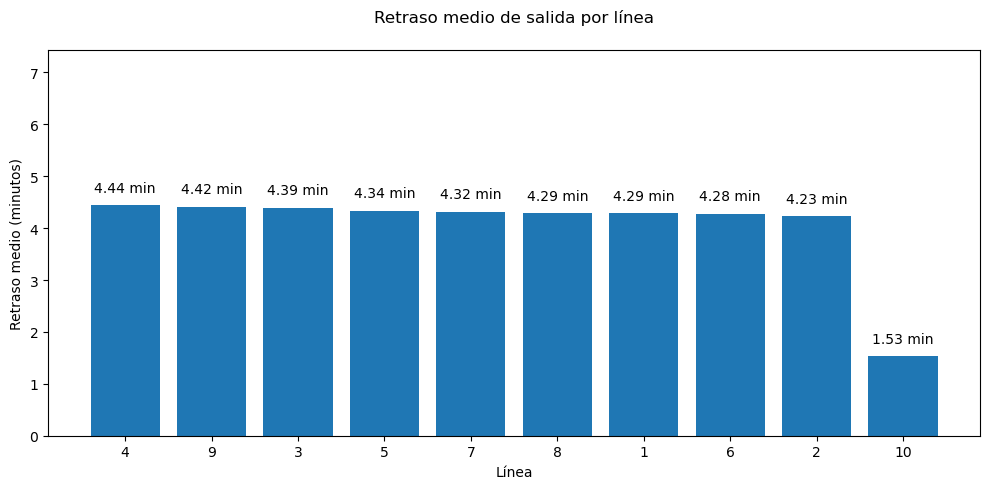

In [49]:
import matplotlib.pyplot as plt
%matplotlib inline

# Filtrar los valores -99 antes de realizar el análisis
fact_viajes_grafico = fact_viajes[
    fact_viajes["retraso_salida_min"] != -99
]

# Calcular el retraso medio de salida por línea
retraso_linea = (
    fact_viajes_grafico
    .groupby("linea_id")["retraso_salida_min"]
    .mean()
    .sort_values(ascending=False)
)

# Crear el gráfico
plt.figure(figsize=(10, 5))

barras = plt.bar(
    retraso_linea.index.astype(str),
    retraso_linea.values
)

# Título y etiquetas
plt.title("Retraso medio de salida por línea", pad=20)
plt.xlabel("Línea")
plt.ylabel("Retraso medio (minutos)")

# Añadir el valor encima de cada barra
for barra, valor in zip(barras, retraso_linea.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.2,
        f"{valor:.2f} min",
        ha="center",
        va="bottom"
    )

# Añadir espacio en la parte superior
plt.ylim(0, retraso_linea.max() + 3)

# Ajustar automáticamente los elementos del gráfico
plt.tight_layout()

# Mostrar el gráfico
plt.show()


### 5.9.2. Demanda por franja horaria

Se analiza el número medio de pasajeros por viaje según la franja horaria para identificar los periodos de mayor demanda.

Este análisis puede ayudar a MetroBus a ajustar frecuencias y capacidad de los vehículos en función de la demanda.

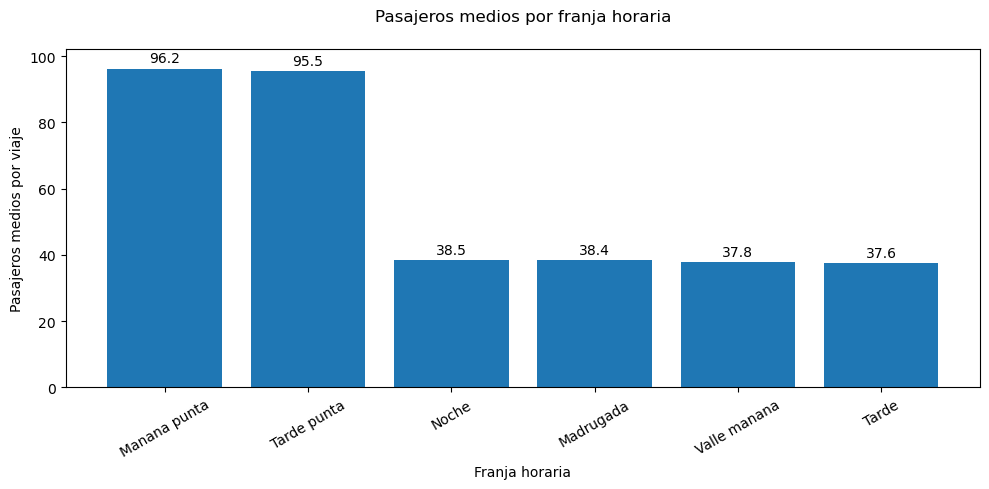

In [60]:
import matplotlib.pyplot as plt

# Calcular el número medio de pasajeros por franja horaria
demanda_franja = (
    fact_viajes
    .groupby("franja_horaria")["pasajeros_subidos"]
    .mean()
    .sort_values(ascending=False)
)

# Crear el gráfico
plt.figure(figsize=(10, 5))

barras = plt.bar(
    demanda_franja.index,
    demanda_franja.values,
)

# Título y etiquetas
plt.title("Pasajeros medios por franja horaria", pad=20)
plt.xlabel("Franja horaria")
plt.ylabel("Pasajeros medios por viaje")

# Girar las etiquetas del eje X para facilitar su lectura
plt.xticks(rotation=30)

# Mostrar el valor encima de cada barra
for barra, valor in zip(barras, demanda_franja.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1,
        f"{valor:.1f}",
        ha="center",
        va="bottom"
    )

# Añadir espacio superior para las etiquetas
plt.ylim(0, demanda_franja.max() + 6)

plt.tight_layout()
plt.show()

### 5.9.3. Ocupación media por línea

Se analiza la ocupación media de los vehículos por línea para identificar aquellas que presentan una mayor utilización de su capacidad.

Este análisis permite detectar posibles diferencias de demanda entre líneas y orientar futuras decisiones sobre asignación de vehículos y frecuencias.

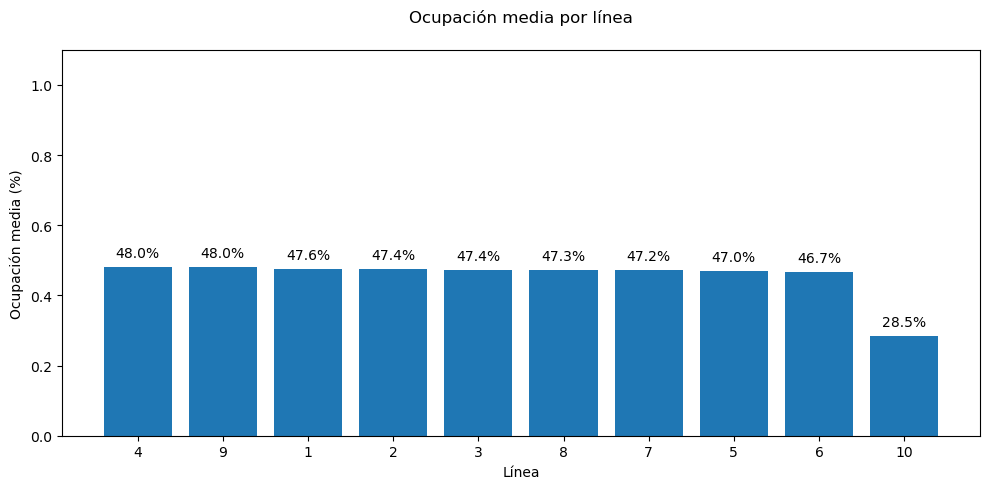

In [56]:
import matplotlib.pyplot as plt

# Calcular la ocupación media por línea
ocupacion_linea = (
    fact_viajes
    .groupby("linea_id")["ocupacion_pct"]
    .mean()
    .sort_values(ascending=False)
)

# Crear el gráfico
plt.figure(figsize=(10, 5))

barras = plt.bar(
    ocupacion_linea.index.astype(str),
    ocupacion_linea.values,
)

# Título y etiquetas
plt.title("Ocupación media por línea", pad=20)
plt.xlabel("Línea")
plt.ylabel("Ocupación media (%)")

# Mostrar el porcentaje encima de cada barra
for barra, valor in zip(barras, ocupacion_linea.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.02,
        f"{valor:.1%}",
        ha="center",
        va="bottom"
    )

# Escala de 0 a 100 % con un pequeño margen superior
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

### 5.9.4. Resumen del análisis visual

Las visualizaciones permiten identificar diferencias en la puntualidad, la demanda y la ocupación entre líneas y franjas horarias.

Los resultados obtenidos servirán como base para seleccionar los principales insights del proyecto y definir posteriormente los indicadores y visualizaciones del cuadro de mando.

## 5.10. Conclusiones del análisis exploratorio

El análisis exploratorio ha permitido conocer la estructura, calidad y comportamiento general de los datos de MetroBus antes de realizar las transformaciones y la construcción del modelo analítico.

### Principales problemas de calidad detectados

Se han identificado los siguientes problemas que deberán ser tratados durante la fase de limpieza:

- La columna `fecha` de `fact_viajes` está almacenada como `object` en lugar de un tipo fecha.
- Las columnas `hora_salida_prog`, `hora_salida_real` y `hora_llegada_real` también están almacenadas como `object` y deberán convertirse a un formato temporal adecuado.
- Se han detectado inconsistencias de formato en `dia_semana`, con valores como `Friday` y `FRIDAY`.
- La variable `combustible` presenta una inconsistencia de capitalización entre `Diesel` y `diesel`.
- Se han identificado valores nulos en `fact_viajes`, `fact_mantenimiento` y algunas tablas de dimensión.
- Se han detectado 580 valores negativos en `retraso_salida_min`, incluyendo 80 registros con el valor `-99`, considerado sospechoso.
- El análisis estadístico ha identificado valores extremos en algunas variables, aunque no todos representan necesariamente errores.
- No se han detectado registros duplicados.
- Los identificadores analizados presentan los niveles de unicidad esperados.
- No se han detectado claves foráneas huérfanas en las relaciones analizadas.
- La ocupación registrada es coherente con los pasajeros y la capacidad de los vehículos.
- No se han detectado viajes con un número de pasajeros superior a la capacidad del vehículo.

### Principales hallazgos

Las visualizaciones exploratorias muestran diferencias entre las líneas en términos de puntualidad y ocupación, así como variaciones en la demanda según la franja horaria.

Estos resultados indican que la puntualidad, la demanda y la utilización de la capacidad son dimensiones relevantes para analizar el funcionamiento operativo de MetroBus.

### Hipótesis de negocio

A partir de los resultados obtenidos se plantean las siguientes hipótesis para las siguientes fases:

1. Algunas líneas pueden presentar un comportamiento de puntualidad significativamente peor que otras.
2. La demanda puede concentrarse en determinadas franjas horarias.
3. Las líneas con mayor demanda pueden presentar mayores niveles de ocupación.
4. El consumo puede estar relacionado con el tipo de combustible, el vehículo y los kilómetros recorridos.
5. Las incidencias y el mantenimiento pueden estar relacionados con determinadas características de los vehículos.

Estas hipótesis se analizarán posteriormente mediante SQL y el cuadro de mando.